SPIKE distance: 0.09614675


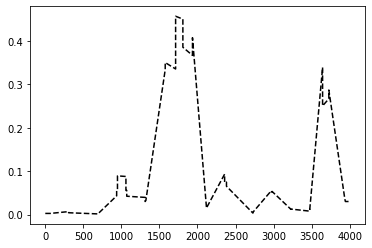

In [2]:
import matplotlib.pyplot as plt
import pyspike as spk

spike_trains = spk.load_spike_trains_from_txt("PySpike_testdata.txt",
                                              edges=(0, 4000))
spike_profile = spk.spike_profile(spike_trains[0], spike_trains[1])
x, y = spike_profile.get_plottable_data()
plt.plot(x, y, '--k')
print("SPIKE distance: %.8f" % spike_profile.avrg())
plt.show()

# 1. Spike train object

- an object that stores spike train.
- note that spike train just consists of many timepoints.
- A SpikeTrain object consists of 
  - the **spike times** given as numpy arrays
  -  as well as the **edges** of the spike train as [t_start, t_end]. 

The following code creates such a spike train with some arbitrary spike times:

In [25]:
import numpy as np
from pyspike import SpikeTrain

spike_train = SpikeTrain(np.array( [[0.1, 0.3, 0.2, 0.4]] ), [0.0, 1.0] )

NameError: name 'SpikeTrains' is not defined

spike_train

In [26]:
spike_trains = spk.load_spike_trains_from_txt("PySpike_testdata.txt",
                                              edges=(0, 4000))
avrg_isi_profile = spk.isi_profile(spike_trains)
avrg_spike_profile = spk.spike_profile(spike_trains)
avrg_spike_sync_profile = spk.spike_sync_profile(spike_trains)

In [36]:
spk.spike_sync(spike_trains[0], spike_trains[1])


0.9375

d

In [2]:
!pip install python-louvain
!pip install networkx

In [ ]:
!conda install -n base ipykernel --update-deps --force-reinstall

: 

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import copy
from networkx.algorithms import community
import matplotlib.animation as animation

In [10]:
Add_Inner_edges(10,1)

[(5, 9, 0.84397113642572)]

In [5]:



def Add_Inner_edges(range, num):
    inner_edges = []
    while len(inner_edges) < num:
        tmp = np.sort(np.random.choice(range, size=2, replace=None)).tolist()
        tmp += [np.random.uniform(0, 1)]  # random weight
        new_edge = tuple(tmp)
        if new_edge not in inner_edges:
            inner_edges = inner_edges + [new_edge]
    return inner_edges


def Add_Outer_edges(Community_all, num):
    # 두 커뮤니티 선택
    outter_edges = []
    while len(outter_edges) < num:
        #group_choiced = np.random.choice(range(len(Community_all)), size=2, replace=None) # 범용적으로 커뮤니티 선택할 시
        if len(outter_edges) < 3:
            group_choiced = np.random.choice([0, 1], size=2, replace=None)
        elif len(outter_edges) < 6:
            group_choiced = np.random.choice([0, 2], size=2, replace=None)
        elif len(outter_edges) < 10:
            group_choiced = np.random.choice([1, 2], size=2, replace=None)
        tmp = np.sort([np.random.choice(Community_all[group_choiced[0]], replace=None),
                 np.random.choice(Community_all[group_choiced[1]], replace=None)]).tolist()
        tmp += [np.random.uniform(0, 1)]  # random weight
        new_edge = tuple(tmp)
        if new_edge not in outter_edges:
            outter_edges = outter_edges + [new_edge]
    return outter_edges


""" Network 생성 """
# 총 150명
G = nx.Graph()
G.add_nodes_from(range(150))
# Community 설정 3개의 커뮤니티
Community1 = range(0, 40)
Community2 = range(40, 90)
Community3 = range(90, 150)
Community_all = Community1, Community2, Community3

# 내부 연결 추가
Inner_edges_1 = Add_Inner_edges(range=Community1, num=100)  # Community 1 100개
Inner_edges_2 = Add_Inner_edges(range=Community2, num=150)  # Community 1 150개
Inner_edges_3 = Add_Inner_edges(range=Community3, num=200)  # Community 1 200개
G.add_weighted_edges_from(Inner_edges_1)
G.add_weighted_edges_from(Inner_edges_2)
G.add_weighted_edges_from(Inner_edges_3)

# 외부 연결 추가
Outter_edges = Add_Outer_edges(Community_all, 50)  # Community 1-2-3 간에 50개
G.add_weighted_edges_from(Outter_edges)
pos = nx.spring_layout(G)

In [9]:
int(3.0)

3

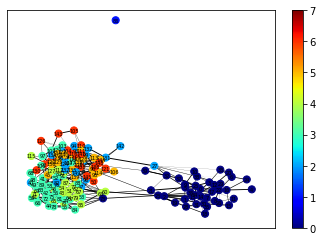

In [15]:
import community as lvcm


""" Louvain method """
partition = lvcm.best_partition(graph=G, partition=None, weight='weight', resolution=1., randomize=True)
max_k_w = []
for com in set(partition.values()):
    list_nodes = [nodes for nodes in partition.keys()
                  if partition[nodes] == com]
    max_k_w = max_k_w + [list_nodes]

""" Make Community Color list """
community_num_group = len(max_k_w)
color_list_community = [[] for i in range(len(G.nodes()))]
for i in range(len(G.nodes())):
    for j in range(community_num_group):
        if i in max_k_w[j]:
            color_list_community[i] = j



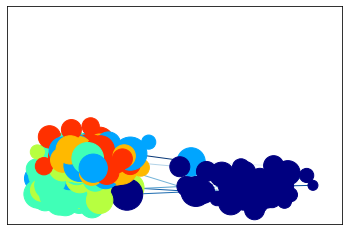

In [31]:
""" Plot Community """
fig, ax = plt.subplots()

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
Feature_color_sub = color_list_community
node_size = 50

d = dict(G.degree)

nx.draw_networkx_nodes(
    G = G, pos = pos,
    nodelist=d.keys(),
    node_size=[v * 100 for v in d.values()],
    node_color=Feature_color_sub,
    cmap='jet',
    vmin=0,
    vmax=community_num_group,
    ax = ax  
    )


nx.draw_networkx_edges(
    G = G, pos = pos,
    edge_color = weights,
    edge_cmap = plt.cm.Blues,
    ax = ax
    )


In [28]:
fig.savefig('save.png')


In [26]:
d.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149])

In [29]:
print(ax)

AxesSubplot(0.125,0.125;0.775x0.755)


In [14]:

plt.xticks([])
plt.yticks([])
plt.colorbar(im)
plt.show(block=False)

AttributeError: 'PathCollection' object has no attribute 'show'

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import copy
from networkx.algorithms import community
import matplotlib.animation as animation
import community as lvcm
import scipy
import pickle
import pandas as pd      

: 

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import copy
from networkx.algorithms import community
import matplotlib.animation as animation
import community as lvcm
import scipy
import pickle
import pandas as pd           
#1.  create network.
distMat = np.load("score_matrix.npy")
print(distMat)
positions = pd.read_pickle("positions.pkl")
print(positions)
n_nodes = distMat.shape[1] # number of nodes = number of channels
G = nx.Graph()

# We set the electrode as a node (e.g., circles in the network map)
channel_list = ["channel{}".format(int(i)) for i in positions[0]]
print(channel_list)
G.add_nodes_from(channel_list)

pos = {}
for i in range(len(channel_list)):
    x_now = positions.iloc[i, 1]
    y_now = positions.iloc[i, 2]
    position_now = [int(x_now), int(y_now)]
    pos[channel_list[i]] = position_now

print(pos[channel_list[1]])
# we set the degree of synchronization between the electrodes as an edge
# (e.g., lines in the network map).
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        sync_score = distMat[i,j]
        # the links with synchronized scores less than 0.5 were filtered out.
        if sync_score >= 1/2:
            G.add_edge(i, j, weight = sync_score)




# Louvain method
partition = lvcm.best_partition(graph=G, partition=None, random_state = 1)
max_k_w = []
for com in set(partition.values()):
    list_nodes = [nodes for nodes in partition.keys() if partition[nodes] == com]
    max_k_w = max_k_w + [list_nodes]
     # list comprehension. concat [member list] of each community

     
# Make Community Color list
community_num_group = len(max_k_w)
color_list_community = [[] for i in range(len(G.nodes()))] # list comprehension. empty list of list

for i in range(len(G.nodes())):
   for j in range(community_num_group):
       if i in max_k_w[j]:
           color_list_community[i] = j
           

# Plot Community           
fig, ax = plt.subplots()
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
Feature_color_sub = color_list_community

d = dict(G.degree)

print(d.keys())

node_size_normalized = np.fromiter(d.values(), dtype = float)
print(node_size_normalized)
node_size_normalized = (node_size_normalized - np.min(node_size_normalized))/(np.max(node_size_normalized) - np.min(node_size_normalized))
nx.draw_networkx_nodes(
    G=G,
    pos = pos,
    nodelist=d.keys(),
    node_size = 30 * (1 + node_size_normalized),
    node_color=Feature_color_sub,
    cmap='jet',
    vmin=0,
    vmax=community_num_group,
    ax = ax )

edges = nx.draw_networkx_edges(
    G = G,
    pos = pos,
    edge_color = weights,
    width = 1.5,
    edge_cmap = plt.cm.Blues,
    ax = ax)
        #    %pyrun("plt.xticks([])")
        #    %pyrun("plt.yticks([])")
plt.colorbar(edges)
        #    %pyrun("plt.show(block=False)")

fig.savefig('networkfig.png')

: 